In [1]:
import numpy as np
import treecorr
from astropy.io import fits
import fitsio
import numpy as np
import Corrfunc
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.io import read_catalog
from Corrfunc.utils import convert_3d_counts_to_cf
from astropy.table import Table, join
from astropy.coordinates import SkyCoord

from multiprocessing import Pool
import pyarrow.parquet as pq
from multiprocessing import Pool, cpu_count
import pyarrow as pa
import matplotlib.pyplot as plt
import scienceplots
import argparse
import multiprocessing
import sys
import healpy as hp
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
randoms_huge= Table.read('/user/animesh.sah/FP_CUTS/randoms_with_mags.fits')
randoms_huge = randoms_huge[randoms_huge['DEC']>-30]

In [3]:
randoms = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read())
randoms = randoms[randoms['DEC']>-30]

In [3]:
randoms_north = randoms_huge[randoms_huge['PHOTSYS'] == 'N']
randoms_south = randoms_huge[randoms_huge['PHOTSYS'] == 'S']


In [4]:
def coords_to_pix(ra_deg, dec_deg, nside,**kwargs):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi,**kwargs)
    return ipix

In [9]:
map = np.zeros(hp.nside2npix(1024), dtype=np.int32)

In [39]:
randoms_north

RA,DEC,NOBS_G,NOBS_R,NOBS_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_Z,MASKBITS,EBV,PHOTSYS,HPXPIXEL,PSFMAG_G,PSFMAG_R,PSFMAG_Z,GALMAG_G,GALMAG_R,GALMAG_Z,PSFMAG_W1,PSFMAG_W2
float64,float64,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,bytes1,int64,float32,float32,float32,float32,float32,float32,float32,float32
208.31659542701468,47.83339277860045,3,3,3,494.53632,164.41783,110.47926,365.88992,111.525604,59.276337,5.1661553,1.7594612,2.198001,1.6124498,1.1692986,0,0.015676213,N,10729,24.120323,23.52251,23.306675,23.956764,23.311794,22.968676,21.644035,21.0593
129.45352317304935,53.90727602763127,3,3,3,811.2731,303.6085,100.443985,579.9076,216.51286,60.30836,3.4081168,1.1844258,1.8916832,1.7651714,1.405102,0,0.034892157,N,7320,24.389034,23.855467,23.254982,24.206774,23.67193,22.978046,21.418219,20.84446
167.00144092624055,60.426109429770584,3,3,4,824.45,261.36423,170.15164,574.24866,168.93459,82.90518,4.5286174,1.6261288,1.6761099,1.569429,1.0383646,0,0.007746238,N,6118,24.397781,23.774132,23.541119,24.20145,23.537224,23.150803,21.572533,21.01652
183.25466500774135,70.96186925414514,3,3,3,652.99744,228.35661,72.27733,488.98773,163.9491,41.787415,5.513898,2.12151,1.9526858,1.8003813,1.2938583,0,0.02171362,N,11967,24.271214,23.700844,23.076326,24.114199,23.520962,22.778883,21.6794,21.160881
104.62345568592823,61.210839067888244,4,3,4,959.69165,286.68558,181.94107,715.61035,191.1308,94.85834,3.4760053,1.287169,2.0243342,1.5659163,1.1233814,0,0.085772514,N,7127,24.48024,23.824331,23.577488,24.320923,23.604239,23.223919,21.428926,20.889618
157.20387207425537,71.31285528712056,4,4,5,1233.3087,237.73987,165.79654,898.8948,187.04333,90.27087,5.11043,1.7857903,1.9107698,2.275107,1.2443246,0,0.075782955,N,7649,24.616415,23.722704,23.527046,24.444712,23.592503,23.19701,21.638147,21.067362
166.48367249222062,52.64032224815478,3,3,3,665.5504,253.60211,111.443016,456.18457,157.96707,61.46062,3.896922,1.2826949,1.8507148,1.4564697,1.2652887,0,0.009048777,N,5986,24.281551,23.757765,23.31139,24.0765,23.500784,22.988321,21.490976,20.88773
138.32652922966216,34.477607213263404,4,3,3,812.92084,141.51671,80.712875,589.8092,107.3963,49.92355,3.141011,0.94683254,1.8077145,2.020326,1.5913413,0,0.017141495,N,5073,24.390135,23.441086,23.136253,24.215965,23.291311,22.875458,21.37391,20.722916
284.7243532054327,49.45517976846191,2,2,4,581.53357,241.2468,107.62619,392.32083,144.18996,60.27053,6.815879,2.8183587,1.6209987,1.300593,1.2820036,0,0.04664925,N,15150,24.208294,23.730652,23.292473,23.994627,23.451244,22.977707,21.794476,21.31507


In [5]:
hpx_north = coords_to_pix(randoms_north['RA'], randoms_north['DEC'], nside=1024)
hpx_south = coords_to_pix(randoms_south['RA'], randoms_south['DEC'], nside=1024)
map_north = np.bincount(hpx_north, minlength=hp.nside2npix(1024))
map_south = np.bincount(hpx_south, minlength=hp.nside2npix(1024))



hpx_north = coords_to_pix(randoms_north['RA'][(randoms_north['PSFDEPTH_Z']>0) &(randoms_north['PSFDEPTH_G']>0)   &(randoms_north['PSFDEPTH_R']>0)], randoms_north['DEC'][(randoms_north['PSFDEPTH_Z']>0) &(randoms_north['PSFDEPTH_G']>0)   &(randoms_north['PSFDEPTH_R']>0)], nside=1024)
hpx_south = coords_to_pix(randoms_south['RA'][(randoms_south['PSFDEPTH_Z']>0) &(randoms_south['PSFDEPTH_G']>0)   &(randoms_south['PSFDEPTH_R']>0)], randoms_south['DEC'][(randoms_south['PSFDEPTH_Z']>0) &(randoms_south['PSFDEPTH_G']>0)   &(randoms_south['PSFDEPTH_R']>0)], nside=1024)
map_north_MASKED = np.bincount(hpx_north, minlength=hp.nside2npix(1024))
map_south_MASKED = np.bincount(hpx_south, minlength=hp.nside2npix(1024))

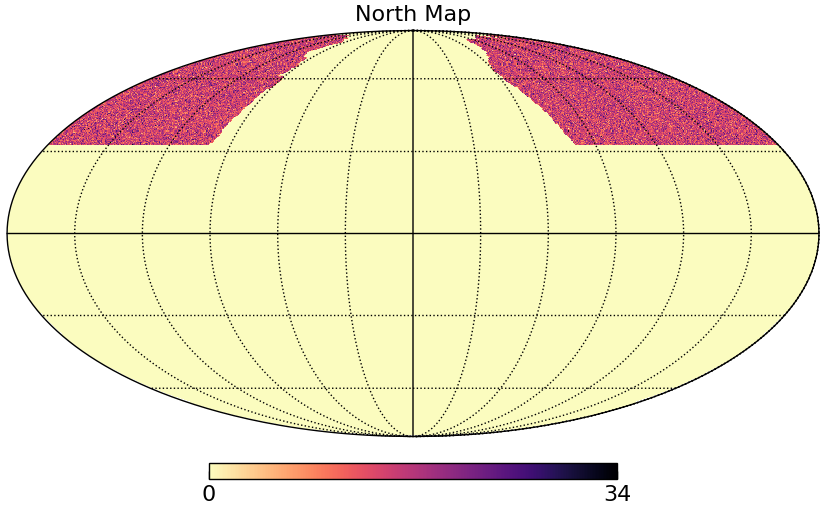

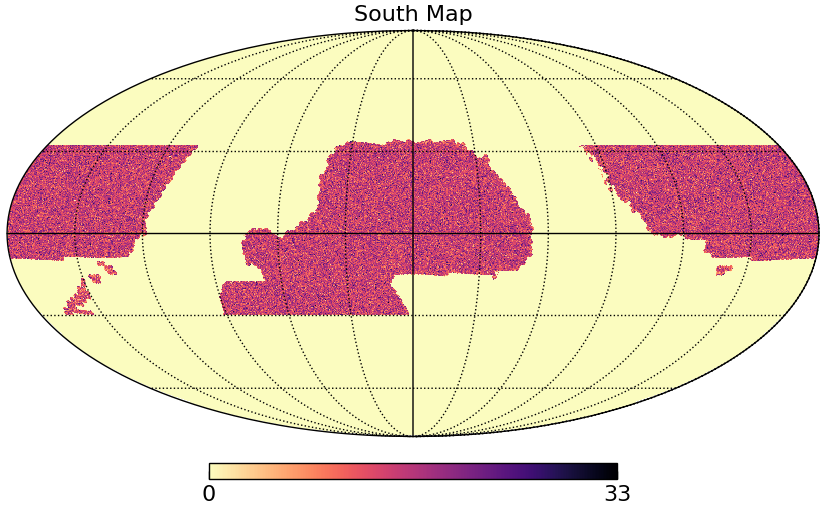

In [6]:
hp.mollview(map_north_MASKED, title='North Map', cmap='magma_r')
hp.graticule()
hp.mollview(map_south_MASKED, title='South Map', cmap='magma_r')
hp.graticule()


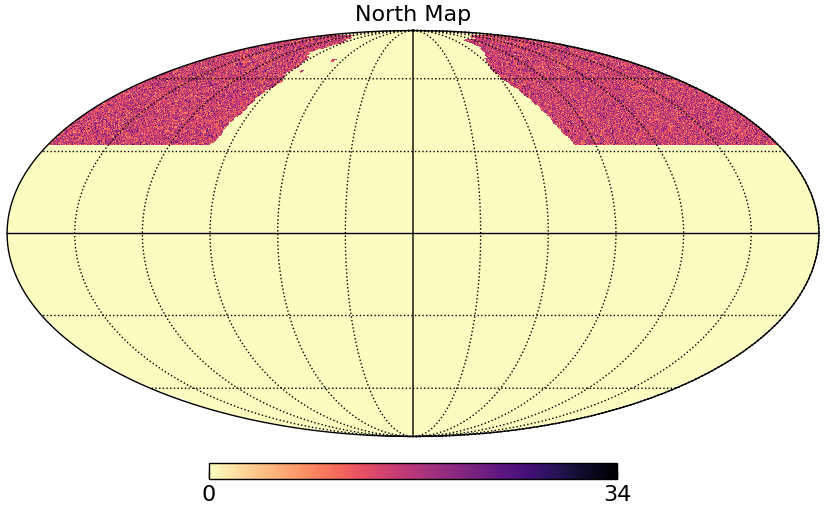

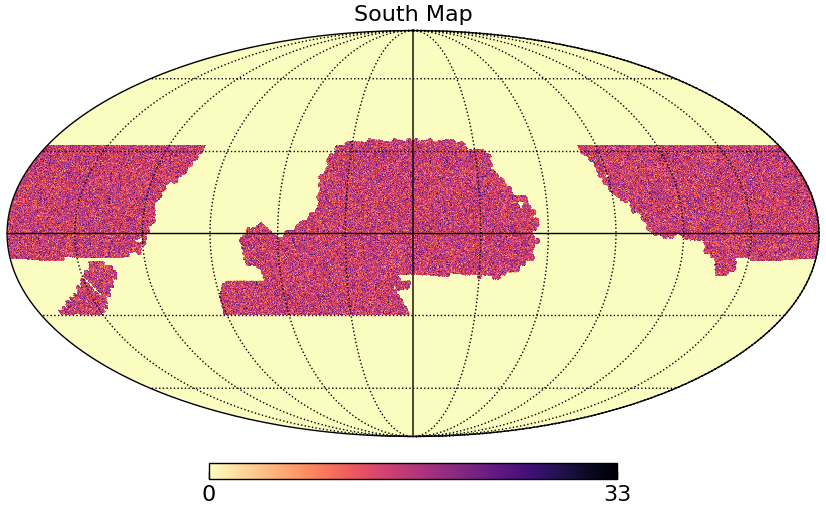

In [10]:
hp.mollview(map_north, title='North Map', cmap='magma_r')
hp.graticule()
hp.mollview(map_south, title='South Map', cmap='magma_r')
hp.graticule()


In [11]:
def compute_magnitudes( legacy):
        """Compute magnitudes and color indices from flux measurements"""
        print("Computing magnitudes and colors...")
        
        MAG = {}
        MAG_NOEXT = {}
        
        for band in ['G', 'R', 'Z', 'W1', 'W2', 'W3']:
            flux = np.array(legacy[f'FLUX_{band}'])
            trans = np.array(legacy[f'MW_TRANSMISSION_{band}'])
            frac = flux / trans
            valid = (frac > 0) & np.isfinite(frac)

            mag = np.full_like(frac, fill_value=np.nan)
            mag_noext = np.full_like(frac, fill_value=np.nan)
            
            # Handle zero/negative fluxes
            
            np.log10(flux, out=mag_noext, where=valid)
            np.log10(frac, out=mag, where=valid)

            MAG[band] = 22.5 - 2.5 * mag
            MAG_NOEXT[band] = 22.5 - 2.5 * mag_noext
            
            legacy[f'MAG_{band}'] = MAG[band]

        # Compute color indices

        color_combinations = [
            ('G', 'R'), ('R', 'Z'), ('G', 'Z'),
            ('W1', 'W2'), ('W2', 'W3'), ('W1', 'W3'),
            ('R', 'W1'), ('R', 'W2'), ('R', 'W3'),
            ('G', 'W1'), ('G', 'W2'), ('G', 'W3'),
            ('Z', 'W1'), ('Z', 'W2'), ('Z', 'W3')
        ]
        
        for band1, band2 in color_combinations:
            legacy[f'MAG_{band1}{band2}'] = legacy[f'MAG_{band1}'] - legacy[f'MAG_{band2}']
        #legacy = self._add_features(legacy)
        
        return legacy


def _add_features( legacy):
    """Add additional features to the dataset"""
    e1,e2 = legacy['SHAPE_E1'], legacy['SHAPE_E2']
    epsilon = np.sqrt(e1**2 + e2**2)
    bba = (1 - epsilon) / (1 + epsilon)
    r_circ = np.sqrt(bba) * legacy['SHAPE_R']
    legacy['BBA'] = bba
    legacy['R_CIRC'] = r_circ
    return legacy



In [12]:
area_north = np.sum(map_north > 0) * hp.nside2pixarea(1024, degrees=True)
area_south = np.sum(map_south > 0) * hp.nside2pixarea(1024, degrees=True)

In [13]:
area_north = np.sum(map_north_MASKED > 0) * hp.nside2pixarea(1024, degrees=True)
area_south = np.sum(map_south_MASKED > 0) * hp.nside2pixarea(1024, degrees=True)

In [14]:
print(f"North Area: {area_north:.2f} deg^2")
print(f"South Area: {area_south:.2f} deg^2")

North Area: 5099.38 deg^2
South Area: 11595.43 deg^2


In [15]:
path ='/storage/shadab/data/legacy_survey/dr9/randoms/randoms-1-2.fits'
with fitsio.FITS(path) as f:
    rows  = f[1].get_nrows()
    randoms_extracted = Table(f[1].read(columns=['RA','DEC','PHOTSYS','PSFDEPTH_G','PSFDEPTH_R','PSFDEPTH_Z']))#,rows=range(10000000)))

In [16]:
randoms_extracted_south  = randoms_extracted[randoms_extracted['PHOTSYS'] == 'S']
randoms_extracted_north  = randoms_extracted[randoms_extracted['PHOTSYS'] == 'N']
randoms_extracted_south  = randoms_extracted_south[randoms_extracted_south['DEC'] > -30]

In [17]:
psf_mask_north= (randoms_extracted_north['PSFDEPTH_Z']>0) & (randoms_extracted_north['PSFDEPTH_R']>0) & (randoms_extracted_north['PSFDEPTH_G']>0)
psf_mask_south= (randoms_extracted_south['PSFDEPTH_Z']>0) & (randoms_extracted_south['PSFDEPTH_R']>0) & (randoms_extracted_south['PSFDEPTH_G']>0)

In [18]:
randoms_extracted_north_masked = randoms_extracted_north[psf_mask_north]
randoms_extracted_south_masked = randoms_extracted_south[psf_mask_south]

In [19]:
area_randoms_north_updated =  len(randoms_extracted_north_masked)  / 2500
area_randoms_south_updated = len(randoms_extracted_south_masked) / 2500
print(f"Area from Randoms (North): {area_randoms_north_updated:.2f} deg^2")
print(f"Area from Randoms (South): {area_randoms_south_updated:.2f} deg^2")

Area from Randoms (North): 5063.46 deg^2
Area from Randoms (South): 11484.06 deg^2


In [21]:
5063.46/5155.73 

0.9821034072769521

In [22]:
11484.06/12179.53

0.9428984533885953

In [20]:
area_randoms_north =  len(randoms_extracted_north)  / 2500
area_randoms_south = len(randoms_extracted_south) / 2500
print(f"Area from Randoms (North): {area_randoms_north:.2f} deg^2")
print(f"Area from Randoms (South): {area_randoms_south:.2f} deg^2")

Area from Randoms (North): 5155.73 deg^2
Area from Randoms (South): 12179.53 deg^2


In [21]:
print('Percentage Difference in Area (North): {:.2f}%'.format(100 * abs(area_north - area_randoms_north) / area_north))
print('Percentage Difference in Area (South): {:.2f}%'.format(100 * abs(area_south - area_randoms_south) / area_south))

Percentage Difference in Area (North): 1.11%
Percentage Difference in Area (South): 5.04%


In [22]:
data_south = Table.read('/user/animesh.sah/FP_CUTS/table_south_unique.fits')
data_north = Table.read('/user/animesh.sah/FP_CUTS/table_north_unique.fits')

In [24]:
DR1_north= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_north_v1_sep_1.fits')[1].read())
DR1_south= Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_DR1_south_v1_sep_1.fits')[1].read())
legacy_north = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_north_v1_sep_1.fits')[1].read())
legacy_south = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/TABLE_legacy_south_v1_sep_1.fits')[1].read())
legacy_south['Z_DR1'] = DR1_south['Z']
legacy_north['Z_DR1'] = DR1_north['Z']
legacy_north = compute_magnitudes(legacy_north)
legacy_south = compute_magnitudes(legacy_south)
legacy_north = _add_features(legacy_north)
legacy_south = _add_features(legacy_south)

Computing magnitudes and colors...
Computing magnitudes and colors...


In [25]:

data_DR1_south = join(legacy_south, data_south, keys=['BRICKID', 'BRICKNAME', 'OBJID'], join_type='inner')
data_DR1_north = join(legacy_north, data_north, keys=['BRICKID', 'BRICKNAME', 'OBJID'], join_type='inner')

In [ ]:
plt.hist(data_DR1_south['MAG_R'],bins = 50, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(data_DR1_north['MAG_R'],bins = 50, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North')
plt.legend()
plt.show()

KeyError: 'MAG_R'

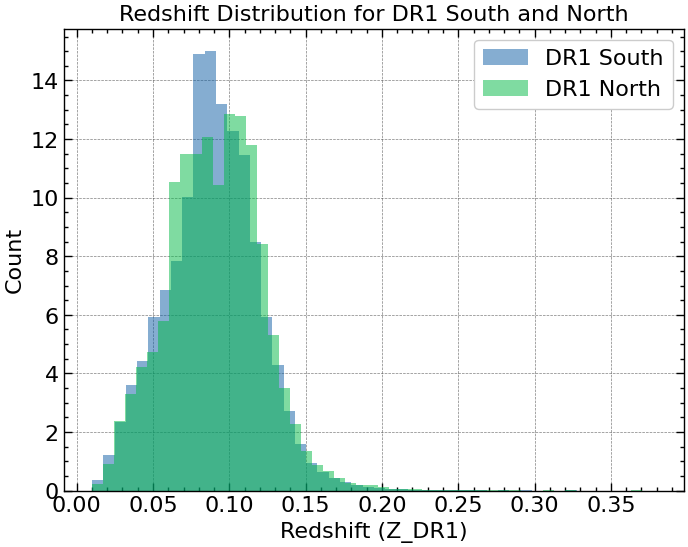

In [ ]:
plt.hist(data_DR1_south['Z_DR1'], bins=50, alpha=0.5, label='DR1 South',density=True)
plt.hist(data_DR1_north['Z_DR1'], bins=50, alpha=0.5, label='DR1 North',density=True)
plt.xlabel('Redshift (Z_DR1)')
plt.ylabel('Count')
plt.title('Redshift Distribution for DR1 South and North')
plt.legend()
plt.show()

In [ ]:
plt.hist(data_DR1_south_subset['Z_DR1'], bins=50, alpha=0.5, label='DR1 South')
plt.hist(data_DR1_north_subset['Z_DR1'], bins=50, alpha=0.5, label='DR1 North')
plt.xlabel('Redshift (Z_DR1)')
plt.ylabel('Count')
plt.title('Redshift Distribution for DR1 South and North')
plt.legend()
plt.show()

NameError: name 'data_DR1_south_subset' is not defined

In [ ]:
data_DR1_south_subset = data_DR1_south[data_DR1_south['Z_DR1'] < 0.15]
data_DR1_north_subset = data_DR1_north[data_DR1_north['Z_DR1'] < 0.15]

plt.hist(data_DR1_south_subset['MAG_R'],bins = 50, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(data_DR1_north_subset['MAG_R'],bins = 50, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North')
plt.legend()
plt.show()

NameError: name 'data_DR1_south' is not defined

In [ ]:
def apply_cuts_phot(table):
    cut1 = (table['MAG_R'] < 18)

    cut2 = cut1 & ((table['MAG_G'] - table['MAG_R']) > 0.68)


    cut3 = cut2 & ((table['MAG_G'] - table['MAG_R']) > (1.3 * (table['MAG_R'] - table['MAG_Z']) - 0.05))

    cut4 = cut3 & ((table['MAG_G'] - table['MAG_R']) < (2.0 * (table['MAG_R'] - table['MAG_Z']) - 0.15))


    cut5 = cut4 & (table['R_CIRC'] > 0)

    cut6 = cut5 & ((1 - table['BBA']) < 0.7)
    cut7 = cut6 & (((table['TYPE'] == 'SER') & (table['SERSIC'] > 2.5)) | (table['TYPE'] == 'DEV'))
    return cut1 & cut2 & cut3 & cut4 & cut5 & cut6 & cut7


def apply_cuts_spec(table,zcut=0.15):
    cut1 = (table['Z_DR1'] < zcut)
    return cut1


In [ ]:
apply_cuts_phot(legacy_south)
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
legacy_north_phot_masked =legacy_north[apply_cuts_phot(legacy_north)]

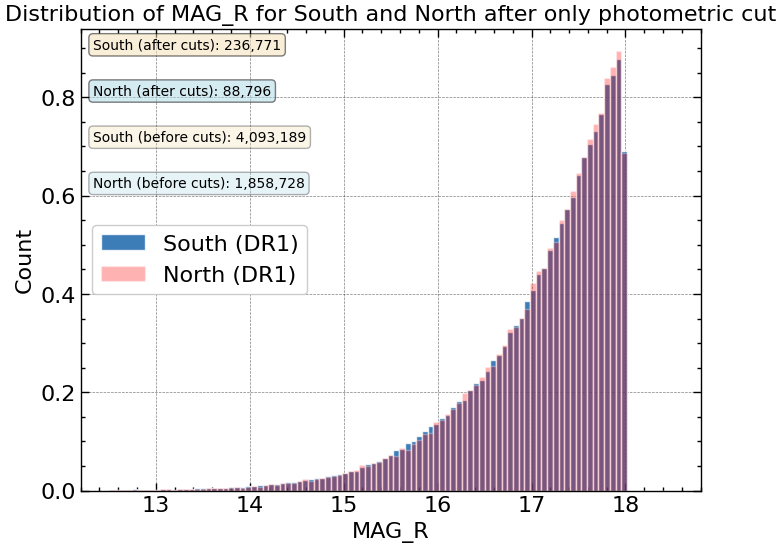

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins  = np.linspace(12.5,18.5,100)
plt.hist(legacy_south_phot_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North after only photometric cut')
plt.legend()
plt.show()

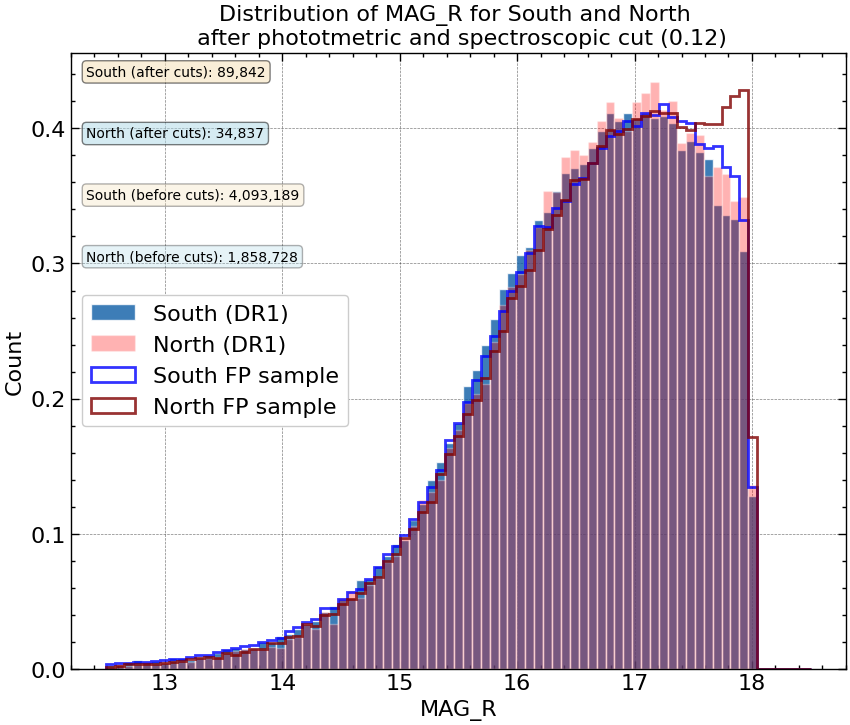

In [ ]:

zspec = 0.12
legacy_south_phot_spec_masked = legacy_south_phot_masked[apply_cuts_spec(legacy_south_phot_masked,zspec)]
legacy_north_phot_spec_masked = legacy_north_phot_masked[apply_cuts_spec(legacy_north_phot_masked,zspec)]
legacy_south_spec_masked = legacy_south[apply_cuts_spec(legacy_south,zspec)]
legacy_north_spec_masked = legacy_north[apply_cuts_spec(legacy_north,zspec)]

legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(12.5,18.5,80)
plt.figure(figsize=(10,8))
plt.hist(legacy_south_phot_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))




plt.hist(data_south['MAG_R'],bins = bins, alpha=0.8, label='South FP sample',density=True,histtype='step',lw=2,color='b')
plt.hist(data_north['MAG_R'],bins = bins, alpha=0.8, label='North FP sample',histtype='step',lw=2,density=True,color='maroon')

plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title(f'Distribution of MAG_R for South and North \n after phototmetric and spectroscopic cut ({zspec})')
plt.legend()
plt.show()

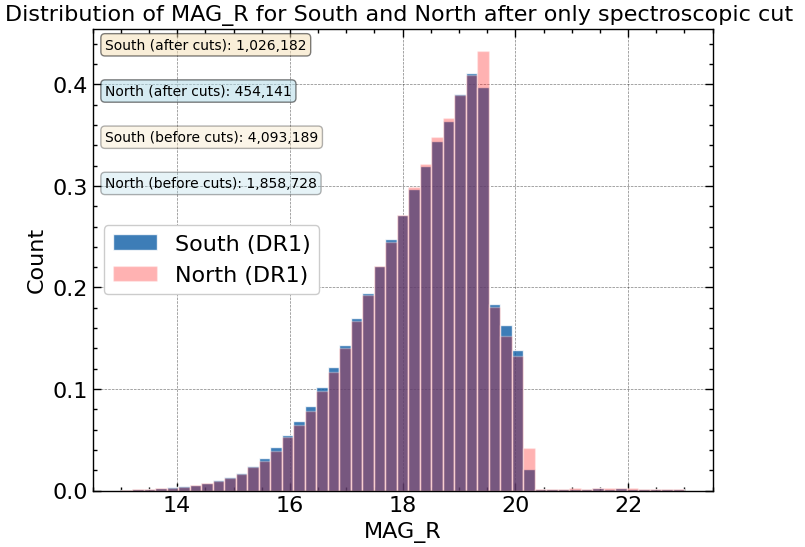

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(13,23,50)
plt.hist(legacy_south_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North after only spectroscopic cut ')
plt.legend()
plt.show()

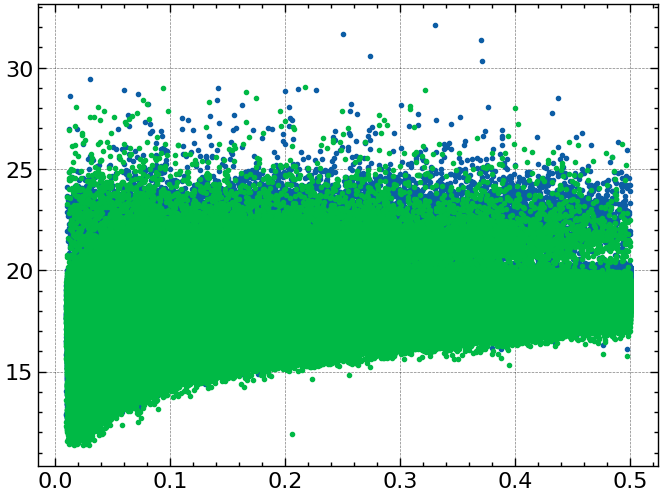

In [ ]:
plt.plot(legacy_south['Z_DR1'],legacy_south['MAG_R'],'.')
plt.plot(legacy_south['Z_DR1'],legacy_south['MAG_Z'],'.')

In [ ]:
legacy_south_phot_masked =legacy_south[apply_cuts_phot(legacy_south)]    
bins = np.linspace(12.5,18.5,80)
plt.figure(figsize=(10,8))
plt.hist(legacy_south_phot_spec_masked['MAG_R'],bins = bins, alpha=0.8, label='South (DR1)',edgecolor='w',density=True)
plt.hist(legacy_north_phot_spec_masked['MAG_R'],bins = bins, alpha=0.3, label='North (DR1)',edgecolor='w',density=True,color='r')  
# Add text boxes with number of elements before and after cuts
plt.text(0.02, 0.98, f'South (after cuts): {len(legacy_south_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text(0.02, 0.88, f'North (after cuts): {len(legacy_north_phot_spec_masked):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.text(0.02, 0.78, f'South (before cuts): {len(legacy_south):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.text(0.02, 0.68, f'North (before cuts): {len(legacy_north):,}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))




plt.hist(data_south['MAG_R'],bins = bins, alpha=0.8, label='South (DR1) FP sample',density=True,histtype='step',lw=2,color='b')
plt.hist(data_north['MAG_R'],bins = bins, alpha=0.8, label='North (DR1) FP sample',histtype='step',lw=2,density=True,color='maroon')

plt.xlabel('MAG_R')
plt.ylabel('Count')
plt.title('Distribution of MAG_R for South and North \n after phototmetric and spectroscopic cut (0.15)')
plt.legend()
plt.show()

In [23]:
Number_density_north = len(data_north) / area_randoms_north_updated
Number_density_south = len(data_south) / area_randoms_south_updated

In [24]:
len(data_north), len(data_south)

(141740, 330821)

In [43]:
np.sqrt(141740)/ area_randoms_north_updated

0.07435302790624744

In [42]:
import numpy as np
np.sqrt(330821)/ area_randoms_south_updated

0.05008423758646805

In [28]:
area_north

5099.377706781366

In [41]:
np.count_nonzero(data_south['DEC']>=32.375)

0

In [37]:
len(data_north) / area_north, len(data_south) / area_south, len(data_north) / area_north - len(data_south) / area_south

(27.795548427704855, 28.530287155514934, -0.734738727810079)

In [36]:
len(data_north) / area_randoms_north_updated, len(data_south) / area_randoms_south_updated, len(data_north) / area_randoms_north_updated -  len(data_south) / area_randoms_south_updated

(27.992705386156743, 28.806971443654195, -0.8142660574974521)

In [28]:
Number_density_north, Number_density_south

(28.408033870897025, 29.554355182597263)

In [34]:
28.4+5*(.07490258584750611)

28.774512929237527

In [8]:
306504 / 12179.53

25.16550310233646

In [56]:
143843/5155.73  , 339404/12179.53 

(27.899637878632127, 27.86675676319201)

In [59]:
27.86675676319201*(0.42/0.40)

29.260094601351607

In [52]:
area_randoms_north_updated

5063.462